<a href="https://colab.research.google.com/github/wasimciit/Python_Programming/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction

In [1]:
pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 20)

# ==================== 1. LOAD DATA ====================

In [4]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85      

In [5]:
print("\nData types and missing values:")
print(df.info())


Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


# ==================== 2. EDA ====================

/tmp/ipython-input-628977825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Survived", data=df, palette="viridis")


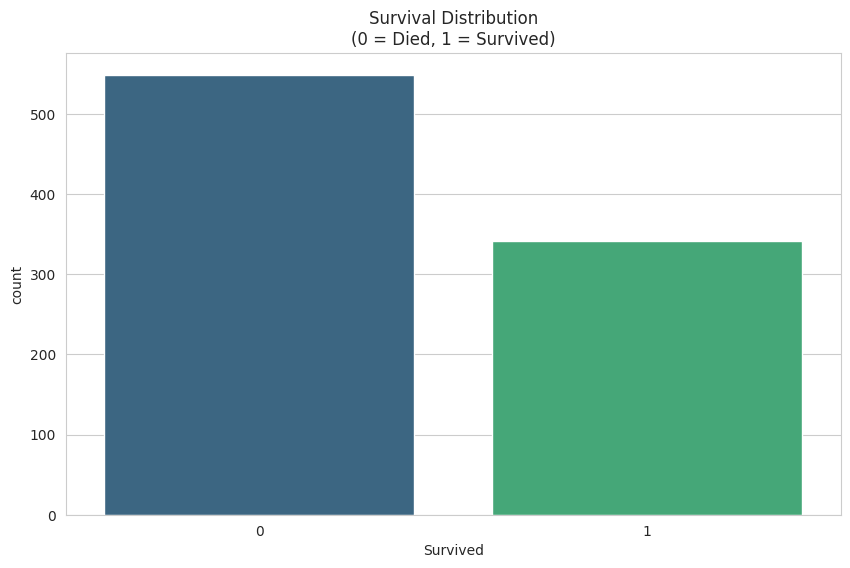

In [6]:
plt.figure()
sns.countplot(x="Survived", data=df, palette="viridis")
plt.title("Survival Distribution\n(0 = Died, 1 = Survived)")
plt.show()

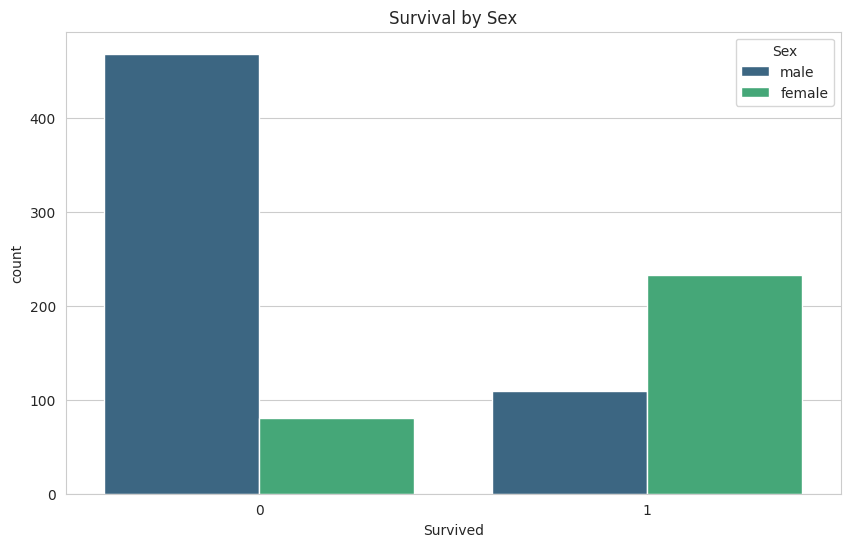

In [7]:
plt.figure()
sns.countplot(x="Survived", hue="Sex", data=df, palette="viridis")
plt.title("Survival by Sex")
plt.show()

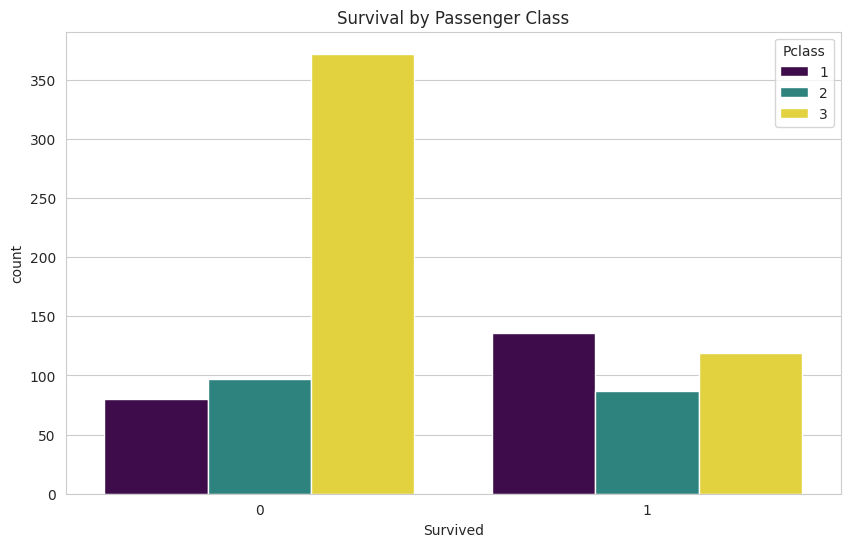

In [8]:
plt.figure()
sns.countplot(x="Survived", hue="Pclass", data=df, palette="viridis")
plt.title("Survival by Passenger Class")
plt.show()

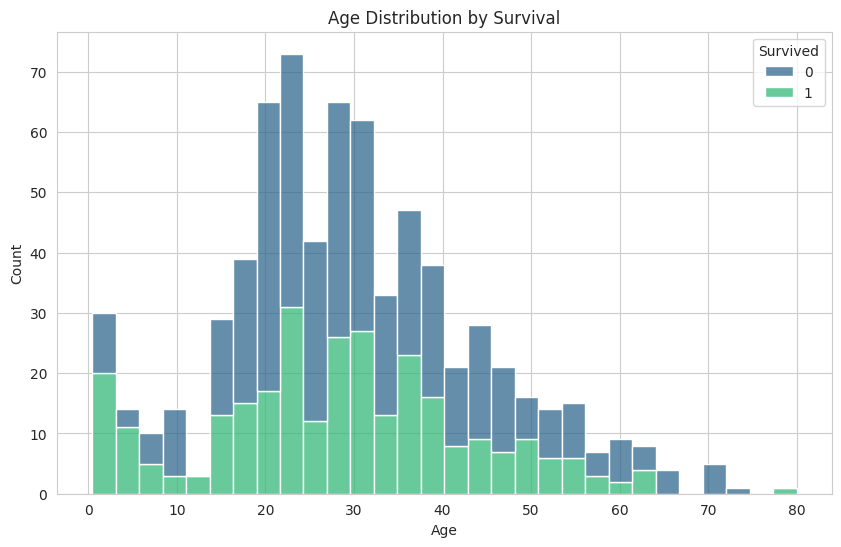

In [9]:
plt.figure()
sns.histplot(data=df, x="Age", hue="Survived", multiple="stack", palette="viridis", bins=30)
plt.title("Age Distribution by Survival")
plt.show()

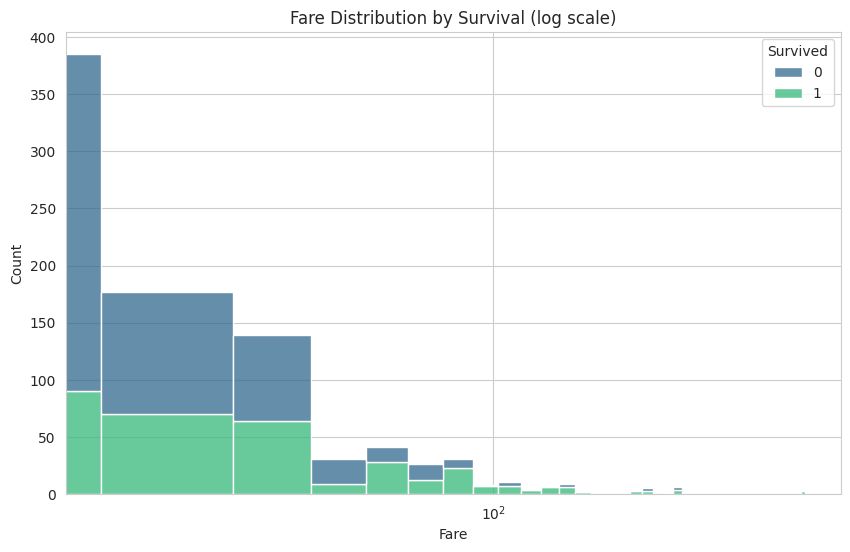

In [10]:
plt.figure()
sns.histplot(data=df, x="Fare", hue="Survived", multiple="stack", palette="viridis", bins=40)
plt.xscale("log")
plt.title("Fare Distribution by Survival (log scale)")
plt.show()

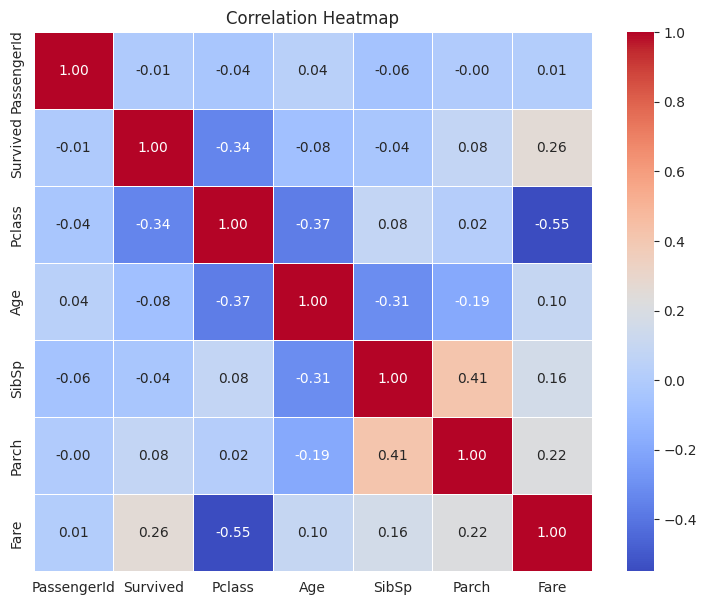

In [11]:
plt.figure(figsize=(9,7))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

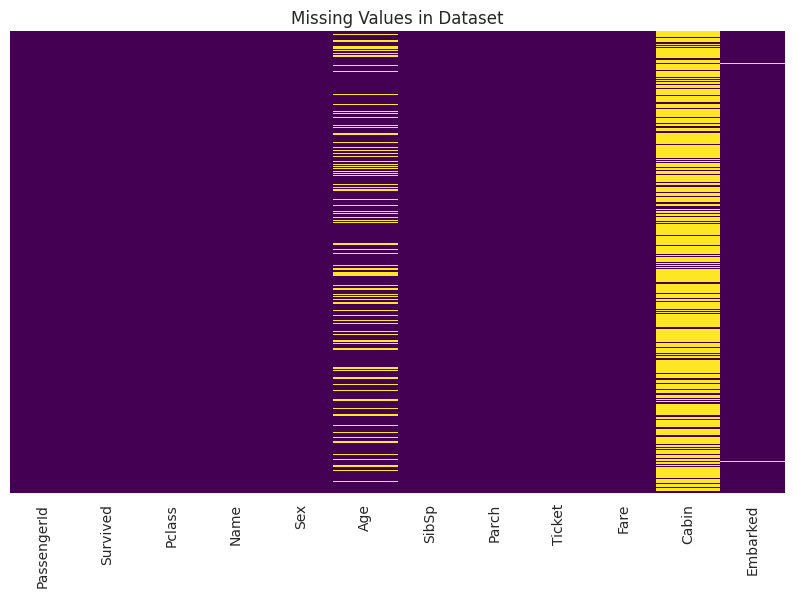

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Values in Dataset")
plt.show()

In [13]:
print("\nMissing values count:")
print(df.isnull().sum())


Missing values count:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# =============== 3. FEATURE ENGINEERING ===============

In [14]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [15]:
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

In [16]:
title_mapping = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Rare", "Countess": "Rare", "Dona": "Rare",
    "Capt": "Rare", "Col": "Rare", "Major": "Rare",
    "Dr": "Rare", "Rev": "Rare", "Sir": "Rare", "Jonkheer": "Rare",
    "Don": "Rare"
}
df["Title"] = df["Title"].replace(title_mapping)

In [17]:
print("\nTitle distribution after grouping:")
print(df["Title"].value_counts())


Title distribution after grouping:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [18]:
columns_to_drop = ["PassengerId", "Name", "Ticket", "Cabin"]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print("\nFinal columns:", df.columns.tolist())


Final columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']


# ================== 4. PREPARE X, y ==================

In [19]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

numeric_features = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
categorical_features = ["Pclass", "Sex", "Embarked", "Title", "IsAlone"]

X["IsAlone"] = X["IsAlone"].astype("object")

# ============== 5. PREPROCESSING PIPELINE ==============

In [20]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

# =============== 6. MODELS TO COMPARE ===============

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

# ========= 7. CROSS-VALIDATION & COMPARISON =========

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

print("\n" + "="*60)
print("5-Fold Cross-Validation Accuracy")
print("="*60)

for name, model in models.items():
    full_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_val_score(
        full_pipeline, X, y,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    mean_score = scores.mean()
    std_score = scores.std()
    results[name] = (mean_score, std_score)

    print(f"{name:20} → {mean_score:.4f} ± {std_score:.4f}")


5-Fold Cross-Validation Accuracy
Logistic Regression  → 0.8305 ± 0.0084
Random Forest        → 0.8159 ± 0.0098
XGBoost              → 0.8440 ± 0.0181


# ========= 8. VISUALIZATION OF MODEL COMPARISON =========

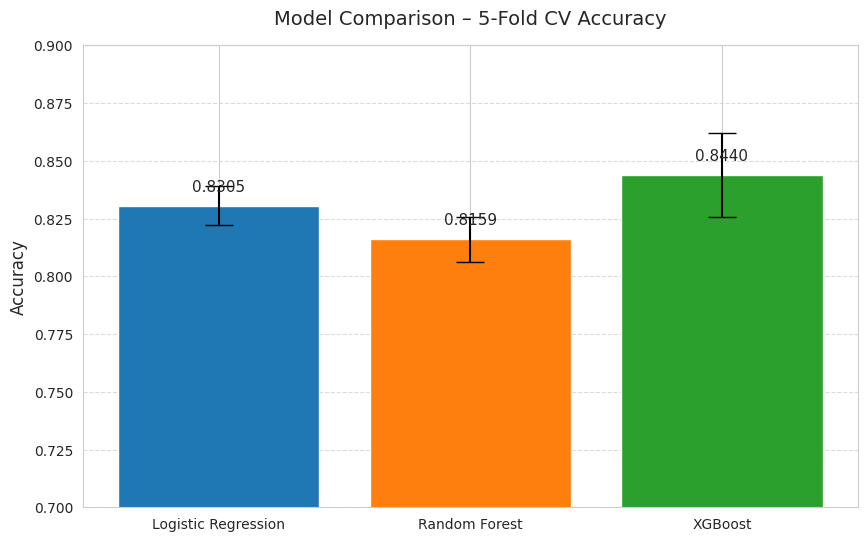


Best performing model: XGBoost (0.8440)


In [23]:
names = list(results.keys())
means = [results[n][0] for n in names]
errors = [results[n][1] for n in names]

plt.figure(figsize=(10,6))
bars = plt.bar(names, means, yerr=errors, capsize=10, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.title("Model Comparison – 5-Fold CV Accuracy", fontsize=14, pad=15)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0.70, 0.90)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}",
             ha="center", va="bottom", fontsize=11)

plt.show()

# Best model
best_model_name = max(results, key=lambda k: results[k][0])
print(f"\nBest performing model: {best_model_name} ({results[best_model_name][0]:.4f})")

# ==== 9. HYPERPERAMETER TUNNING & MODEL COMPARISON ====

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─── Logistic Regression ───────────────────────────────────────
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42, solver="liblinear"))
])

lr_param_grid = [
    {
        "classifier__C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
        "classifier__penalty": ["l1", "l2"]
    }
]

# ─── Random Forest ─────────────────────────────────────────────
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_grid = [
    {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [None, 8, 12, 16],
        "classifier__min_samples_split": [2, 5],
        "classifier__min_samples_leaf": [1, 2]
    }
]

# ─── XGBoost ───────────────────────────────────────────────────
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=-1))
])

xgb_param_grid = [
    {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [3, 4, 5, 6],
        "classifier__learning_rate": [0.01, 0.05, 0.1],
        "classifier__subsample": [0.8, 1.0],
        "classifier__colsample_bytree": [0.8, 1.0]
    }
]

In [25]:
from sklearn.model_selection import GridSearchCV
models = {
    "Logistic Regression": (lr_pipe, lr_param_grid),
    "Random Forest": (rf_pipe, rf_param_grid),
    "XGBoost": (xgb_pipe, xgb_param_grid)
}

results = {}
best_estimators = {}

print("\n" + "="*70)
print("GridSearchCV – Best Parameters & CV Score")
print("="*70)

for name, (pipe, param_grid) in models.items():
    print(f"\nTuning {name}...")

    grid_search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        verbose=1,
        return_train_score=False
    )

    grid_search.fit(X, y)

    best_score = grid_search.best_score_
    best_params = grid_search.best_params_
    best_estimators[name] = grid_search.best_estimator_

    results[name] = {
        "best_cv_score": best_score,
        "best_params": best_params
    }

    print(f"→ Best CV accuracy: {best_score:.4f}")
    print(f"→ Best parameters:")
    for k, v in best_params.items():
        print(f"   {k:35} : {v}")


GridSearchCV – Best Parameters & CV Score

Tuning Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
→ Best CV accuracy: 0.8305
→ Best parameters:
   classifier__C                       : 1.0
   classifier__penalty                 : l2

Tuning Random Forest...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
→ Best CV accuracy: 0.8417
→ Best parameters:
   classifier__max_depth               : None
   classifier__min_samples_leaf        : 2
   classifier__min_samples_split       : 2
   classifier__n_estimators            : 200

Tuning XGBoost...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
→ Best CV accuracy: 0.8518
→ Best parameters:
   classifier__colsample_bytree        : 1.0
   classifier__learning_rate           : 0.1
   classifier__max_depth               : 3
   classifier__n_estimators            : 100
   classifier__subsample               : 0.8


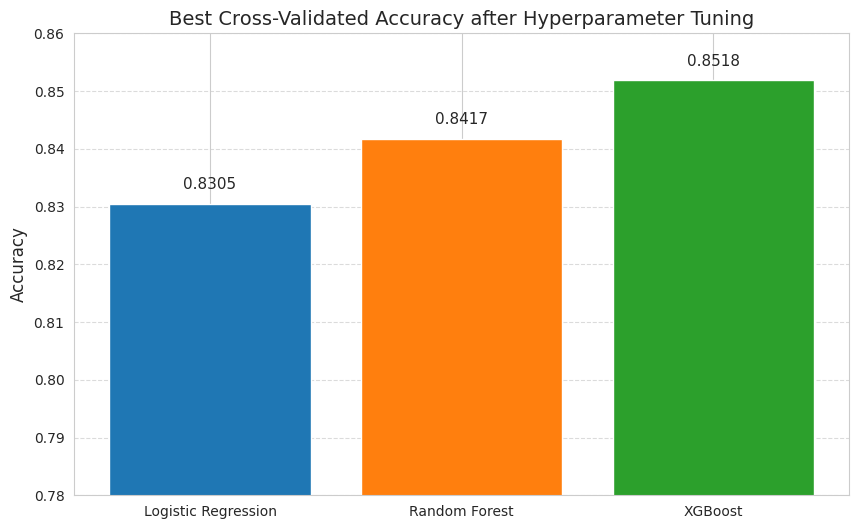


WINNER: XGBoost
Best CV score: 0.8518
Best parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}


In [26]:
names = list(results.keys())
scores = [results[n]["best_cv_score"] for n in names]

plt.figure(figsize=(10, 6))
bars = plt.bar(names, scores, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.title("Best Cross-Validated Accuracy after Hyperparameter Tuning", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0.78, 0.86)
plt.grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.4f}",
             ha="center", va="bottom", fontsize=11)

plt.show()

# Show winner
best_model = max(results, key=lambda k: results[k]["best_cv_score"])
print("\n" + "="*70)
print(f"WINNER: {best_model}")
print(f"Best CV score: {results[best_model]['best_cv_score']:.4f}")
print("Best parameters:", results[best_model]["best_params"])
print("="*70)

# ========= 10. LEARNING CURVES =========

In [27]:
best_estimators = {}
best_scores = {}

print("\n" + "="*65)
print("GridSearchCV Results")
print("="*65)

for name, (pipe, param_grid) in models.items():
    print(f"\nTuning {name}...")
    grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy",
                        n_jobs=-1, verbose=0)
    grid.fit(X, y)

    best_estimators[name] = grid.best_estimator_
    best_scores[name] = grid.best_score_

    print(f"→ Best accuracy: {grid.best_score_:.4f}")
    print("   Best params:", grid.best_params_)


GridSearchCV Results

Tuning Logistic Regression...
→ Best accuracy: 0.8305
   Best params: {'classifier__C': 1.0, 'classifier__penalty': 'l2'}

Tuning Random Forest...
→ Best accuracy: 0.8417
   Best params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

Tuning XGBoost...
→ Best accuracy: 0.8518
   Best params: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}


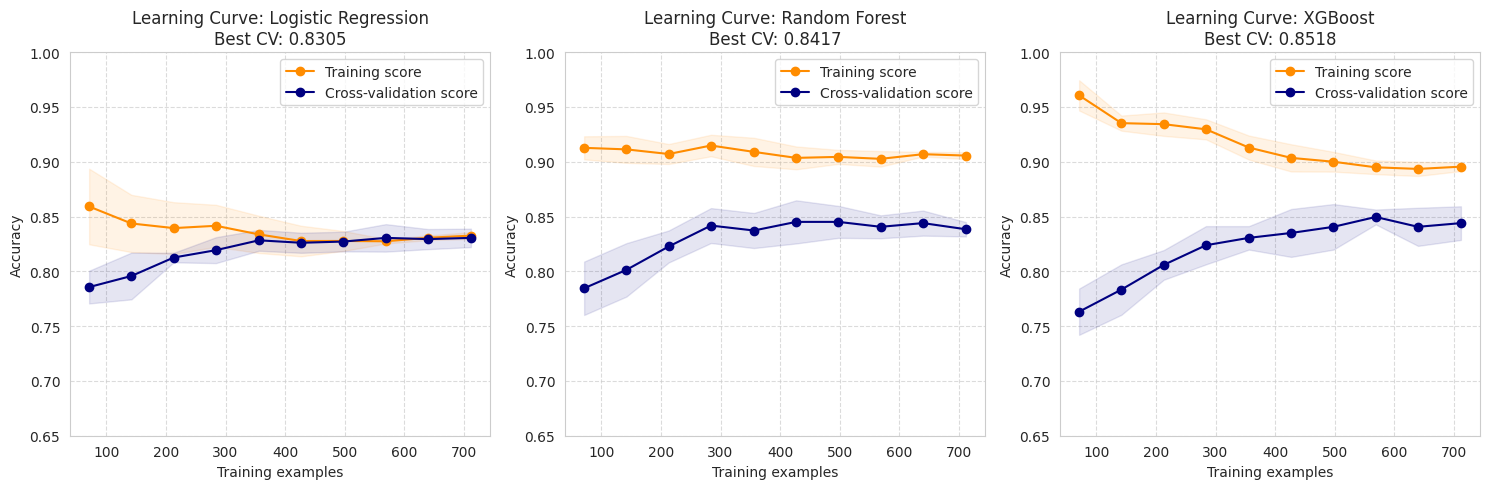

In [28]:
from sklearn.model_selection import learning_curve
train_sizes = np.linspace(0.1, 1.0, 10)

plt.figure(figsize=(15, 5))

for i, (name, estimator) in enumerate(best_estimators.items(), 1):
    plt.subplot(1, 3, i)

    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator,
        X, y,
        cv=cv,
        train_sizes=train_sizes,
        scoring="accuracy",
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)
    val_std    = np.std(val_scores, axis=1)

    plt.plot(train_sizes_abs, train_mean, "o-", color="darkorange", label="Training score")
    plt.plot(train_sizes_abs, val_mean,   "o-", color="navy",       label="Cross-validation score")

    plt.fill_between(train_sizes_abs, train_mean - train_std,
                     train_mean + train_std, alpha=0.1, color="darkorange")
    plt.fill_between(train_sizes_abs, val_mean - val_std,
                     val_mean + val_std, alpha=0.1, color="navy")

    plt.title(f"Learning Curve: {name}\nBest CV: {best_scores[name]:.4f}")
    plt.xlabel("Training examples")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.ylim(0.65, 1.0)

plt.tight_layout()
plt.show()

# ========= 11. RESULT'S INTERPERTATION =========

### Model Comparison Summary

| Model               | Best CV Score | Bias (Underfitting) | Variance (Overfitting) | Interpretation                                 |
|---------------------|---------------|----------------------|-------------------------|------------------------------------------------|
| Logistic Regression | ~0.8305        | High                | Low                     | Too simple – misses non-linear patterns & interactions |
| Random Forest       | ~0.8417        | Low                 | Moderate–High           | Strong learner, but tends to overfit           |
| **XGBoost**         | **~0.8518**    | Low                 | Low–Moderate            | **Best generalization**, most robust model     |

### Learning Curve Insights

- **Logistic Regression**  
  Both curves plateau early at low accuracy → **high bias** → needs more complex model

- **Random Forest**  
  Training accuracy very high, validation noticeably lower → **overfitting** → could benefit from stronger regularization or pruning

- **XGBoost**  
  Smallest gap, highest validation score → **well-balanced** → captures patterns effectively without excessive memorization

**Conclusion**:  
XGBoost is the most suitable model for this task.  
Future work could include stacking, feature selection, or target encoding to push performance closer to 0.86+.